In [1]:
import shap
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import joblib
import numpy as np
from scipy.sparse import issparse


In [2]:
predictions = pd.read_parquet('predictions.parquet', engine='pyarrow')
predictions.head()

,id,clean_text,text,party,sentiment
0,1844361929781113331,many failure bidens administration directly tr...,@a_newsman Many failures of Bidens administrat...,democrat,negative
1,1844361929550332320,lie biden told american misinformation set exa...,@atensnut The lies Biden told Americans about ...,democrat,negative
2,1844361928925384711,someone talented fundraising team,@TheDemocrats here’s someone very talented for...,democrat,positive
3,1844361928585654516,chipper usd card working expressionless face,@LifeOfNapaul Chipper USD card isn’t working 😑,democrat,negative
4,1844361927495123076,yes n't done live interview real journalist si...,@MTGrepp Yes. She hasn't done a live interview...,democrat,positive


In [3]:
train = pd.read_parquet('train_labelled.parquet', engine='pyarrow')
train.head()

,clean_text,party,sentiment,sentiment_score
0,maga maha trumpvance2024 trump2024 magamovemen...,republican,positive,0.8479
1,favorite post kamala harris pretending like de...,democrat,positive,0.8545
2,ron desantis signed sb304 price gouging back a...,democrat,positive,0.8979
3,200 people dead hurricane 99 republican voted ...,republican,negative,-0.8662
4,wtaf coward afraid 60 minute 're incapable tel...,republican,negative,-0.9712


## Party Classifier

In [4]:
X_train, y_train = train['clean_text'], train['party']
X_test, y_test = predictions['clean_text'], predictions['party']

SAMPLE_SIZE = 10000
TOTAL_RECORDS = len(X_test)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS

_, sample_indices, _, _ = train_test_split(
    y_test.index,
    y_test,
    test_size=test_ratio,
    stratify=y_test,
    random_state=42
)

X_sample_test = X_test.loc[sample_indices]
y_sample_test = y_test.loc[sample_indices]


In [5]:
print(len(X_sample_test))
print(len(y_sample_test))

10000
10000


In [ ]:
party_model = joblib.load("models/LightGBM_party_classifier.joblib")
tfidf = party_model.named_steps["tfidf"]
lgb_model = party_model.named_steps["clf"]

X_sample_test_tfidf = tfidf.transform(X_sample_test)

In [ ]:
print("TF-IDF shape:", X_sample_test_tfidf.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

In [ ]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_sample_test_tfidf)

In [ ]:
print(type(shap_values.values), shap_values.values.shape)


In [ ]:
feature_names = tfidf.get_feature_names_out()

shap_dense = shap_values.values.toarray()  # shape: (10000, 20000)
X_dense = X_sample_test_tfidf.toarray()

shap.initjs()

shap.summary_plot(shap_dense, features=X_dense, feature_names=feature_names)


In [ ]:
# shap.initjs()

# shap.plots.bar(shap.Explanation(values=shap_values[1000], 
#                                 base_values=explainer.expected_value,
#                                 feature_names=feature_names))

In [ ]:
# Mean absolute SHAP values per feature
mean_abs_shap = np.abs(shap_dense).mean(axis=0)

# Top 50 features
top_idx = np.argsort(mean_abs_shap)[-50:]
feature_names_top = feature_names[top_idx]
shap_top = shap_dense[:, top_idx]
X_top = X_dense[:, top_idx]

# Global feature importance bar plot
shap.summary_plot(shap_top, features=X_top, feature_names=feature_names_top, plot_type="bar")


In [ ]:
positive_class = lgb_model.classes_[1]  # positive class
negative_class = lgb_model.classes_[0]  # negative class

print(positive_class)

In [ ]:
mean_shap = shap_dense.mean(axis=0)
feature_importance_df_dir = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': mean_shap
}).sort_values(by='Mean_SHAP', ascending=False)

feature_importance_df_dir['Direction'] = feature_importance_df_dir['Mean_SHAP'].apply(
    lambda x: positive_class if x > 0 else negative_class
)
feature_importance_df_dir.head(10)


## Democrat Sentiment Classifier

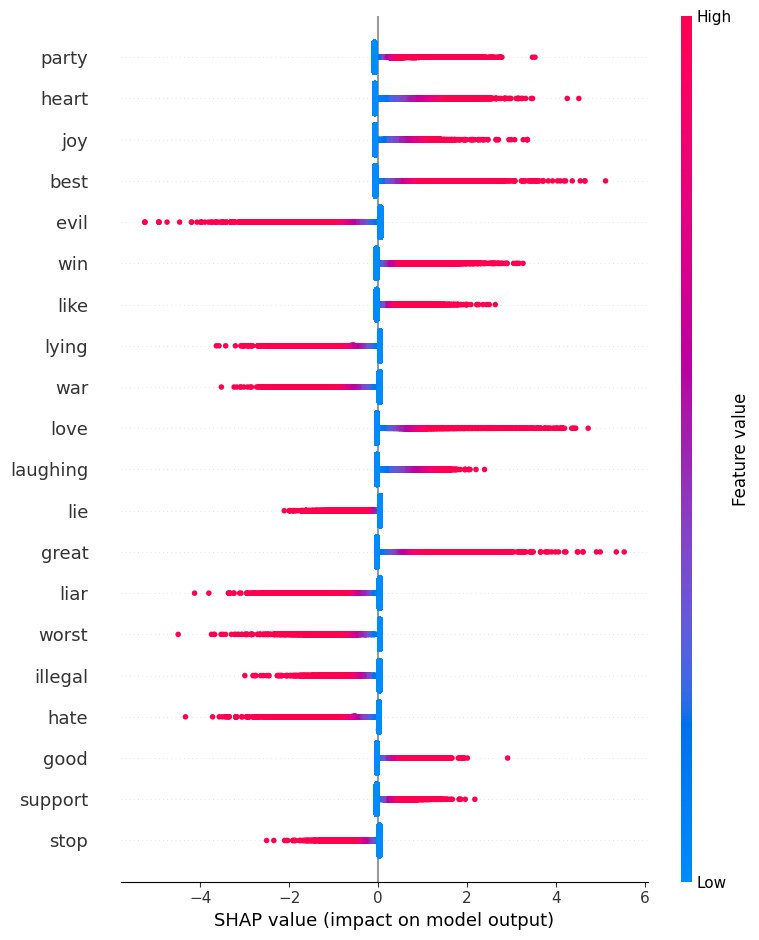

In [58]:
model = joblib.load("models/LinearSVC_democrat_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

democrat_df = labelled_df[labelled_df['party'] == 'democrat'].copy()

democrat_tfidf = tfidf.transform(democrat_df['clean_text'])

democrat_tfidf_dense = democrat_tfidf.toarray()

explainer = shap.LinearExplainer(clf, democrat_tfidf_dense)
shap_values = explainer.shap_values(democrat_tfidf_dense)

shap.summary_plot(
    shap_values, 
    democrat_tfidf_dense, 
    feature_names=tfidf.get_feature_names_out(),
    title="SHAP Summary: Democratic Sentiment Classification"
)

In [76]:
target_shap_values = np.array(shap_values)
    
print(f"Target SHAP matrix shape being used: {target_shap_values.shape}")

Target SHAP matrix shape being used: (413612, 10000)


In [77]:
target_shap_values = shap_values[1]
feature_names_all = tfidf.get_feature_names_out() 

N_features_in_shap = target_shap_values.shape[0]
feature_names = feature_names_all[:N_features_in_shap]

print("Global Feature Importance (Top 10 by Mean Absolute SHAP)")
mean_abs_shap = np.abs(target_shap_values)

global_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values(by='Mean_Abs_SHAP', ascending=False)

global_importance_df.head(10)

SyntaxError: '(' was never closed (988210437.py, line 2)

In [56]:
class_labels = clf.classes_
print(class_labels)

['negative' 'positive']


In [63]:
print("Directional Feature Importance (Top 10 by Mean Signed SHAP)")
mean_signed_shap = np.mean(target_shap_values, axis=0)

directional_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Signed_SHAP': mean_signed_shap
}).sort_values(by='Mean_Signed_SHAP', ascending=False)

print("Strongest Positive Sentiment Signals:")
directional_importance_df.head(5)

Directional Feature Importance (Top 10 by Mean Signed SHAP)
Strongest Positive Sentiment Signals:


,Feature,Mean_Signed_SHAP
9868,worst,0.021218
3366,evil,0.019441
5337,lie,0.019374
5313,liar,0.013361
5091,killer,0.013134


In [61]:
print("Strongest Negative Sentiment Signals:")
directional_importance_df.tail(5)

Strongest Negative Sentiment Signals:


,Feature,Mean_Signed_SHAP
8601,terrorist,-0.015932
6462,party,-0.021003
4422,heart,-0.022570
916,best,-0.034491
5000,joy,-0.040457


## Republican Sentiment Classifier

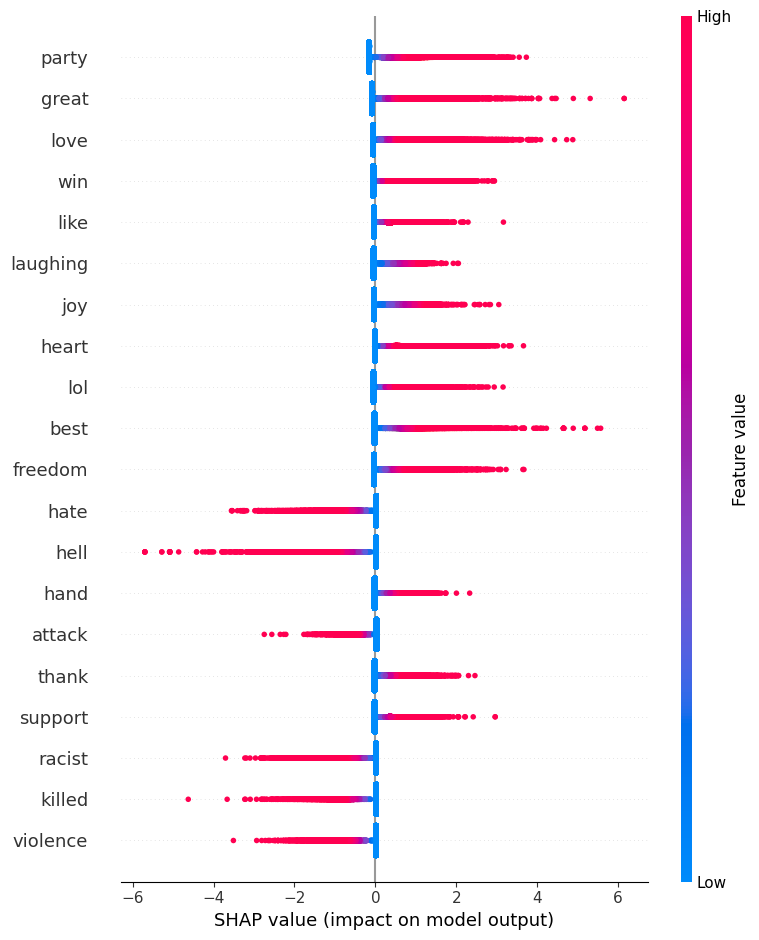

In [7]:

model = joblib.load("models/LinearSVC_republican_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

republican_df = labelled_df[labelled_df['party'] == 'republican'].copy()

republican_tfidf = tfidf.transform(republican_df['clean_text'])
republican_tfidf_dense = republican_tfidf.toarray()

explainer = shap.LinearExplainer(clf, republican_tfidf_dense)
shap_values = explainer.shap_values(republican_tfidf_dense)

shap.summary_plot(
    shap_values, 
    republican_tfidf_dense,
    feature_names=tfidf.get_feature_names_out(),
    title="SHAP Summary: Republican Sentiment Classification"
)